In [19]:
# ==========================================
# 1. CARREGAMENTO DE PACOTES
# ==========================================

#Pacotes

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scikit_posthocs as sp
import warnings

from sklearn.model_selection import RepeatedKFold, train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans


warnings.filterwarnings('ignore')

In [10]:
# ==========================================
# 1. CARREGAMENTO E VISUALIZAÇÃO DOS DADOS
# ==========================================

# 1. Definir os nomes das colunas de acordo com o ficheiro de atributos
columns = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free",
    "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit",
    "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money",
    "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650",
    "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857",
    "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology",
    "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct",
    "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project",
    "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_semicolon", "char_freq_parenthesis", "char_freq_bracket",
    "char_freq_exclamation", "char_freq_dollar", "char_freq_hash",
    "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total", "is_spam"
]

# 2. Carregar o ficheiro CSV/data sem cabeçalho
df = pd.read_csv("spambase.data", header=None, names=columns)

# 3. Métodos para visualização inicial
print(df.head())          # Exibe as primeiras 5 linhas tabuladas
print(df.info())          # Resumo de tipos e valores nulos
print(df["is_spam"].value_counts()) # Proporção entre spam (1) e legítimo (0)

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_semicolon  \
0             0.00            0.00  ...                 0.00   
1           

Iniciando varredura dos pares (K, H) com 100 repetições cada...
Par (K=2, H=1) -> Menor W = 256513.75 | Silhueta = 0.2961
Par (K=2, H=2) -> Menor W = 244486.70 | Silhueta = 0.6596
Par (K=3, H=1) -> Menor W = 254414.01 | Silhueta = 0.2515
Par (K=3, H=2) -> Menor W = 239373.66 | Silhueta = 0.2454
Par (K=3, H=3) -> Menor W = 234585.87 | Silhueta = 0.1409
Par (K=4, H=1) -> Menor W = 253278.68 | Silhueta = 0.0484
Par (K=4, H=2) -> Menor W = 233358.70 | Silhueta = 0.2428
Par (K=4, H=3) -> Menor W = 228516.44 | Silhueta = 0.1620
Par (K=4, H=4) -> Menor W = 227058.69 | Silhueta = 0.1536

Melhor combinação (K, H): (2, 2)
Número ótimo de clusters de objetos K* = 2 (Silhueta máxima = 0.6596)



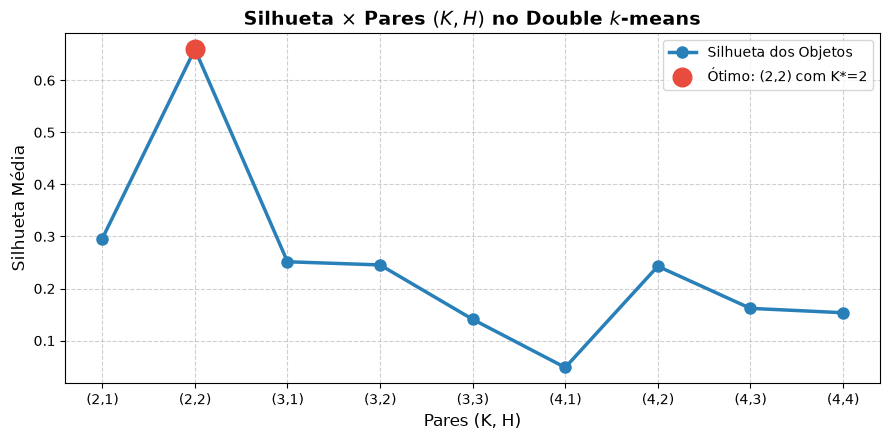

Índice de Rand Corrigido (ARI) para K* = 2: -0.0049
Comentário: O ARI varia de -1 a 1 (sendo 0 o valor esperado ao acaso e 1 partição idêntica).

--- Matriz de Protótipos dos Blocos (G) ---
               Bloco_Var_1  Bloco_Var_2
Cluster_Obj_1    -0.051080     0.001075
Cluster_Obj_2     6.861185    -0.144405


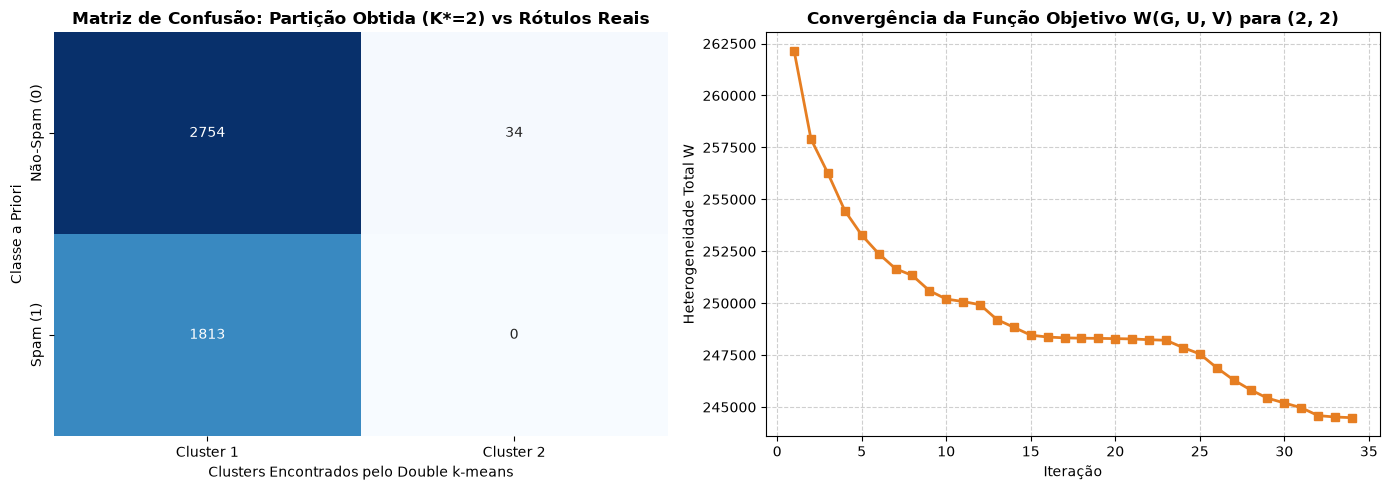

In [11]:
# ==========================================
# 1. QUESTÃO
# ==========================================
# 2. IMPLEMENTAÇÃO DO DOUBLE K-MEANS
# ==========================================

# --- DEFINIÇÃO DE X E y_true ---
# Separa atributos (X) e classe real (y_true)
X_raw = df.drop(columns=["is_spam"]).values
y_true = df["is_spam"].values

# No Double k-means, padronizar as colunas (z-score) é fundamental
# para que variáveis com escalas muito distintas (ex: run_length) não dominem os blocos
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)


def double_kmeans(X, K, H, max_iter=100, tol=1e-6, random_state=None):
    """
    Algoritmo Double k-means:
    Minimiza: W(G, U, V) = sum_{k=1}^K sum_{h=1}^H sum_{i=1}^N sum_{j=1}^P u_ik * v_jh * (x_ij - g_kh)^2
    """
    rng = np.random.RandomState(random_state)
    N, P = X.shape

    # Inicialização aleatória das pertinências crisp U e V
    u_labels = rng.randint(0, K, size=N)
    v_labels = rng.randint(0, H, size=P)

    # Garantir que todos os grupos tenham ao menos um elemento
    for k in range(K):
        if not np.any(u_labels == k):
            u_labels[rng.choice(N)] = k
    for h in range(H):
        if not np.any(v_labels == h):
            v_labels[rng.choice(P)] = h

    G = np.zeros((K, H))
    W_history = []

    for iteration in range(max_iter):
        # Passo 1: Otimização dos protótipos dos blocos g_kh
        for k in range(K):
            idx_obj = np.where(u_labels == k)[0]
            for h in range(H):
                idx_var = np.where(v_labels == h)[0]
                if len(idx_obj) > 0 and len(idx_var) > 0:
                    G[k, h] = np.mean(X[np.ix_(idx_obj, idx_var)])
                else:
                    G[k, h] = 0.0

        # Passo 2: Atualização da pertinência dos objetos (U)
        # Calcula a distância do objeto i até cada grupo de objetos k considerando os clusters de variáveis H
        # Dist_obj[i, k] = sum_h sum_{j in Q_h} (x_ij - g_kh)^2
        dist_u = np.zeros((N, K))
        for h in range(H):
            idx_var = np.where(v_labels == h)[0]
            if len(idx_var) == 0:
                continue
            X_sub = X[:, idx_var] # (N, n_h)
            for k in range(K):
                # Erro quadrático somado sobre as variáveis do bloco h
                dist_u[:, k] += np.sum((X_sub - G[k, h]) ** 2, axis=1)

        new_u_labels = np.argmin(dist_u, axis=1)

        # Evitar cluster de objetos vazio
        for k in range(K):
            if not np.any(new_u_labels == k):
                worst_obj = np.argmax(np.min(dist_u, axis=1))
                new_u_labels[worst_obj] = k

        # Passo 3: Atualização da pertinência das variáveis (V)
        # Dist_var[j, h] = sum_k sum_{i in P_k} (x_ij - g_kh)^2
        dist_v = np.zeros((P, H))
        for k in range(K):
            idx_obj = np.where(new_u_labels == k)[0]
            if len(idx_obj) == 0:
                continue
            X_sub = X[idx_obj, :] # (n_k, P)
            for h in range(H):
                dist_v[:, h] += np.sum((X_sub - G[k, h]) ** 2, axis=0)

        new_v_labels = np.argmin(dist_v, axis=1)

        # Evitar cluster de variáveis vazio
        for h in range(H):
            if not np.any(new_v_labels == h):
                worst_var = np.argmax(np.min(dist_v, axis=1))
                new_v_labels[worst_var] = h

        # Cálculo da Função Objetivo W(G, U, V)
        W = 0.0
        for k in range(K):
            idx_obj = np.where(new_u_labels == k)[0]
            for h in range(H):
                idx_var = np.where(new_v_labels == h)[0]
                if len(idx_obj) > 0 and len(idx_var) > 0:
                    W += np.sum((X[np.ix_(idx_obj, idx_var)] - G[k, h]) ** 2)

        W_history.append(W)

        # Critério de convergência: estabilização da atribuição ou estagnação da perda
        if np.array_equal(new_u_labels, u_labels) and np.array_equal(new_v_labels, v_labels):
            u_labels, v_labels = new_u_labels, new_v_labels
            break
        if iteration > 0 and abs(W_history[-2] - W_history[-1]) < tol:
            u_labels, v_labels = new_u_labels, new_v_labels
            break

        u_labels, v_labels = new_u_labels, new_v_labels

    return G, u_labels, v_labels, W, W_history

# ==========================================================
# 3. EXPERIMENTO: 100 EXECUÇÕES PARA CADA (K, H) E SILHUETA
# ==========================================================

K_values = [2, 3, 4]
results = {}
grid_pairs = []

print("Iniciando varredura dos pares (K, H) com 100 repetições cada...")

for K in K_values:
    for H in range(1, K + 1):
        pair = (K, H)
        grid_pairs.append(pair)
        best_W = np.inf
        best_run = None

        for run in range(100):
            G, u_labels, v_labels, W, W_hist = double_kmeans(
                X, K=K, H=H, max_iter=60, random_state=run * 100 + K * 10 + H
            )
            if W < best_W:
                best_W = W
                best_run = {
                    "G": G,
                    "u_labels": u_labels,
                    "v_labels": v_labels,
                    "W": W,
                    "W_history": W_hist
                }

        # Cálculo da silhueta para a partição de objetos
        sil = silhouette_score(X, best_run["u_labels"])
        best_run["silhouette"] = sil
        results[pair] = best_run

        print(f"Par (K={K}, H={H}) -> Menor W = {best_W:.2f} | Silhueta = {sil:.4f}")

# ==========================================================
# 4. DETERMINAÇÃO DE K* E PLOT Sil x (K, H)
# ==========================================================

pair_labels = [f"({k},{h})" for (k, h) in grid_pairs]
sil_values = [results[pair]["silhouette"] for pair in grid_pairs]

best_pair = grid_pairs[np.argmax(sil_values)]
K_star = best_pair[0]

print("\n" + "="*50)
print(f"Melhor combinação (K, H): {best_pair}")
print(f"Número ótimo de clusters de objetos K* = {K_star} (Silhueta máxima = {max(sil_values):.4f})")
print("="*50 + "\n")

# Gráfico da Silhueta x (K, H)
plt.figure(figsize=(9, 4.5))
plt.plot(pair_labels, sil_values, marker='o', color="#2980b9", linewidth=2.5, markersize=8, label="Silhueta dos Objetos")
max_idx = np.argmax(sil_values)
plt.scatter([pair_labels[max_idx]], [sil_values[max_idx]], color="#e74c3c", s=180, zorder=5,
            label=f"Ótimo: {pair_labels[max_idx]} com K*={K_star}")

plt.title("Silhueta $\\times$ Pares $(K, H)$ no Double $k$-means", fontsize=14, fontweight="bold")
plt.xlabel("Pares (K, H)", fontsize=12)
plt.ylabel("Silhueta Média", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# ==========================================================
# 5. AVALIAÇÃO DA PARTIÇÃO COM K*
# ==========================================================

optimal_run = results[best_pair]
u_star = optimal_run["u_labels"]
G_star = optimal_run["G"]
W_history_star = optimal_run["W_history"]

# (a) Índice de Rand Corrigido (ARI)
ari = adjusted_rand_score(y_true, u_star)
print(f"Índice de Rand Corrigido (ARI) para K* = {K_star}: {ari:.4f}")
print("Comentário: O ARI varia de -1 a 1 (sendo 0 o valor esperado ao acaso e 1 partição idêntica).")

# (b) Matriz de Protótipos dos Blocos (G)
print("\n--- Matriz de Protótipos dos Blocos (G) ---")
df_prototypes = pd.DataFrame(
    G_star,
    index=[f"Cluster_Obj_{k+1}" for k in range(K_star)],
    columns=[f"Bloco_Var_{h+1}" for h in range(best_pair[1])]
)
print(df_prototypes)

# (c) Matriz de Confusão: Partição Obtida vs Partição a Priori
cm = confusion_matrix(y_true, u_star)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
            xticklabels=[f"Cluster {k+1}" for k in range(K_star)],
            yticklabels=["Não-Spam (0)", "Spam (1)"], ax=axes[0])
axes[0].set_title(f"Matriz de Confusão: Partição Obtida (K*={K_star}) vs Rótulos Reais", fontweight="bold")
axes[0].set_xlabel("Clusters Encontrados pelo Double k-means")
axes[0].set_ylabel("Classe a Priori")

# (d) Plot da Função Objetivo versus Iterações
axes[1].plot(range(1, len(W_history_star) + 1), W_history_star, marker='s', color="#e67e22", linewidth=2)
axes[1].set_title(f"Convergência da Função Objetivo W(G, U, V) para {best_pair}", fontweight="bold")
axes[1].set_xlabel("Iteração")
axes[1].set_ylabel("Heterogeneidade Total W")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


INICIANDO EXPERIMENTO 30x10-FOLDS PARA: Spambase (Original - 2 Classes)
  -> Processando Repetição 1/30...
  -> Processando Repetição 2/30...
  -> Processando Repetição 3/30...
  -> Processando Repetição 4/30...
  -> Processando Repetição 5/30...
  -> Processando Repetição 6/30...
  -> Processando Repetição 7/30...
  -> Processando Repetição 8/30...
  -> Processando Repetição 9/30...
  -> Processando Repetição 10/30...
  -> Processando Repetição 11/30...
  -> Processando Repetição 12/30...
  -> Processando Repetição 13/30...
  -> Processando Repetição 14/30...
  -> Processando Repetição 15/30...
  -> Processando Repetição 16/30...
  -> Processando Repetição 17/30...
  -> Processando Repetição 18/30...
  -> Processando Repetição 19/30...
  -> Processando Repetição 20/30...
  -> Processando Repetição 21/30...
  -> Processando Repetição 22/30...
  -> Processando Repetição 23/30...
  -> Processando Repetição 24/30...
  -> Processando Repetição 25/30...
  -> Processando Repetição 26/30...


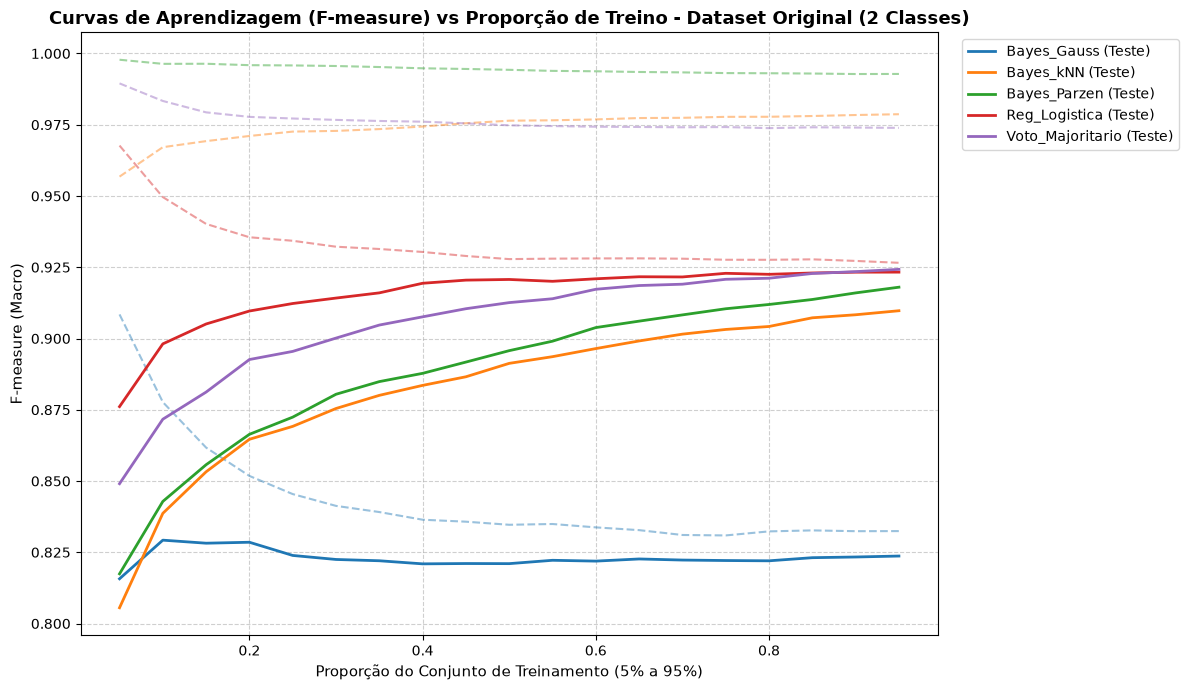

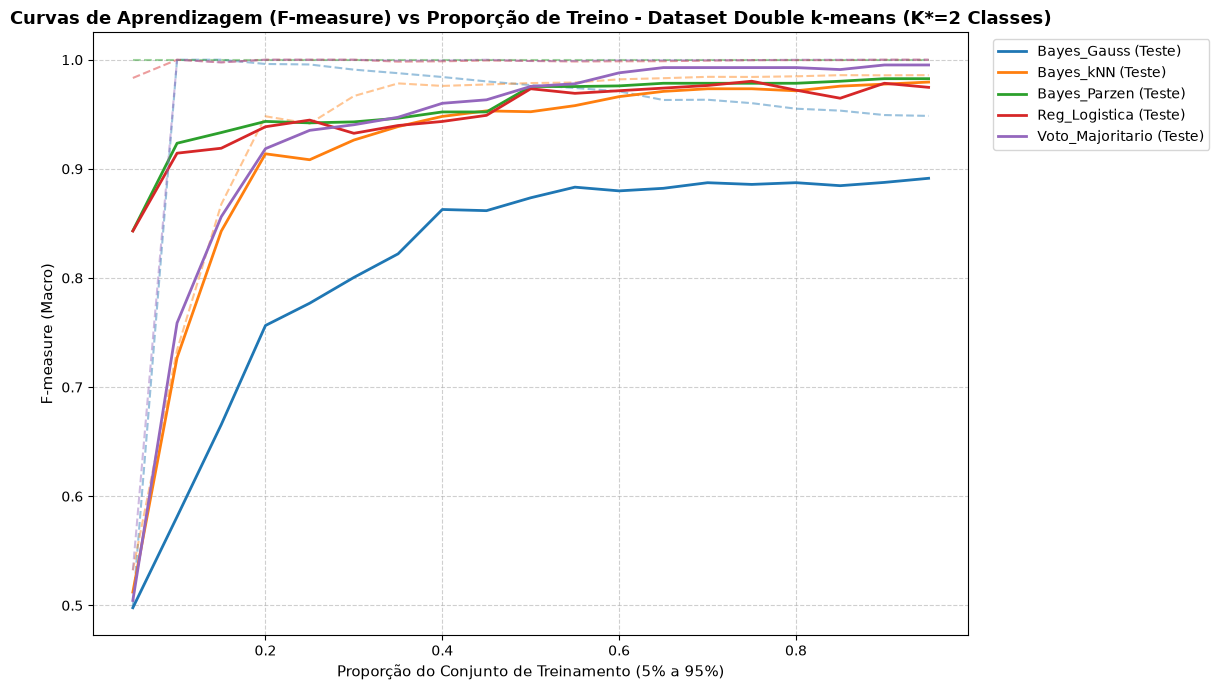

In [20]:
# ==============================================================================
# DEFINIÇÃO DOS CLASSIFICADORES CUSTOMIZADOS EXIGIDOS NA QUESTÃO 2
# ==============================================================================

# ==============================================================================
# 1. DEFINIÇÃO DOS CLASSIFICADORES CUSTOMIZADOS EXIGIDOS NA QUESTÃO 2
# ==============================================================================

# ------------------------------------------------------------------------------
# i) Classificador Bayesiano Gaussiano (Normal Multivariada com MV)
# ------------------------------------------------------------------------------
class GaussianBayesClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.covs_ = {}
        n_samples, self.d_ = X.shape
        
        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / n_samples
            self.means_[c] = np.mean(X_c, axis=0)
            cov = np.cov(X_c, rowvar=False) + 1e-6 * np.eye(self.d_)
            self.covs_[c] = cov
        return self

    def predict_proba(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        posteriors = np.zeros((n_samples, n_classes))

        for idx_c, c in enumerate(self.classes_):
            prior = self.priors_[c]
            mean = self.means_[c]
            cov = self.covs_[c]
            
            try:
                pdf = stats.multivariate_normal.pdf(X, mean=mean, cov=cov, allow_singular=True)
            except Exception:
                pdf = np.zeros(n_samples)
                
            posteriors[:, idx_c] = pdf * prior

        sum_post = np.sum(posteriors, axis=1, keepdims=True)
        sum_post[sum_post == 0] = 1e-15
        return posteriors / sum_post

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


# ------------------------------------------------------------------------------
# ii) Classificador Bayesiano baseado em k-Vizinhos (k-NN com distâncias)
# ------------------------------------------------------------------------------
class KNNBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_neighbors=5, metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.metric = metric

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.knn = KNeighborsClassifier(n_neighbors=self.n_neighbors, metric=self.metric)
        self.knn.fit(X, y)
        return self

    def predict(self, X):
        return self.knn.predict(X)

    def predict_proba(self, X):
        return self.knn.predict_proba(X)


# ------------------------------------------------------------------------------
# iii) Classificador Bayesiano por Janela de Parzen (Kernel Gaussiano)
# ------------------------------------------------------------------------------
class ParzenBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, h=1.0):
        self.h = h

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.X_by_class_ = {}
        n_samples = len(y)
        for c in self.classes_:
            X_c = X[y == c]
            self.priors_[c] = len(X_c) / n_samples
            self.X_by_class_[c] = X_c
        self.d_ = X.shape[1]
        return self

    def _parzen_pdf_sample(self, x, X_c):
        diff = x - X_c
        dists_sq = np.sum(diff ** 2, axis=1)
        k_val = np.exp(-0.5 * dists_sq / (self.h ** 2))
        coeff = (2 * np.pi) ** (-self.d_ / 2.0) * (self.h ** (-self.d_))
        return np.mean(k_val) * coeff

    def predict_proba(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        posteriors = np.zeros((n_samples, n_classes))

        for idx_c, c in enumerate(self.classes_):
            X_c = self.X_by_class_[c]
            prior = self.priors_[c]
            pdf_vals = np.zeros(n_samples)
            for i in range(n_samples):
                pdf_vals[i] = self._parzen_pdf_sample(X[i], X_c)
            posteriors[:, idx_c] = pdf_vals * prior

        sum_post = np.sum(posteriors, axis=1, keepdims=True)
        sum_post[sum_post == 0] = 1e-15
        return posteriors / sum_post

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]


# ==============================================================================
# 2. PIPELINE COMPLETO DE VALIDAÇÃO CRUZADA 30x10-FOLDS
# ==============================================================================

def run_full_q2_evaluation(X_data, y_labels, dataset_name="Original"):
    print(f"\n==================================================")
    print(f"INICIANDO EXPERIMENTO 30x10-FOLDS PARA: {dataset_name}")
    print(f"==================================================")
    
    n_reps = 30
    n_splits = 10
    clf_names = ['Bayes_Gauss', 'Bayes_kNN', 'Bayes_Parzen', 'Reg_Logistica', 'Voto_Majoritario']
    metrics_list = ['Taxa_Erro', 'Precision', 'Recall', 'F1_Measure']
    
    results_matrix = {clf: {m: np.zeros(n_reps) for m in metrics_list} for clf in clf_names}
    
    train_fractions = np.linspace(0.05, 0.95, 19)
    learning_curves = {
        clf: {
            'train': np.zeros((n_reps, len(train_fractions))),
            'test': np.zeros((n_reps, len(train_fractions)))
        } for clf in clf_names
    }

    param_grids = {
        'Bayes_kNN': {
            'n_neighbors': [1, 3, 5, 7, 9],
            'metric': ['euclidean', 'manhattan', 'chebyshev']
        },
        'Bayes_Parzen': {
            'h': [0.1, 0.5, 1.0, 2.0]
        },
        'Reg_Logistica': {
            'C': [0.01, 0.1, 1.0, 10.0]
        }
    }

    for rep in range(n_reps):
        print(f"  -> Processando Repetição {rep+1}/{n_reps}...")
        rkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42 + rep)
        
        fold_metrics = {clf: {m: [] for m in metrics_list} for clf in clf_names}
        
        for train_idx, test_idx in rkf.split(X_data, y_labels):
            X_tr, X_te = X_data[train_idx], X_data[test_idx]
            y_tr, y_te = y_labels[train_idx], y_labels[test_idx]

            scaler = StandardScaler()
            X_tr = scaler.fit_transform(X_tr)
            X_te = scaler.transform(X_te)

            # 1. Bayesiano Gaussiano
            clf_gauss = GaussianBayesClassifier()
            clf_gauss.fit(X_tr, y_tr)

            # 2. Bayesiano k-NN
            grid_knn = GridSearchCV(
                KNNBayesClassifier(), param_grids['Bayes_kNN'], 
                cv=5, scoring='f1_macro', n_jobs=-1
            )
            grid_knn.fit(X_tr, y_tr)
            clf_knn = grid_knn.best_estimator_

            # 3. Bayesiano Parzen
            grid_parzen = GridSearchCV(
                ParzenBayesClassifier(), param_grids['Bayes_Parzen'], 
                cv=5, scoring='f1_macro', n_jobs=2
            )
            grid_parzen.fit(X_tr, y_tr)
            clf_parzen = grid_parzen.best_estimator_

            # 4. Regressão Logística
            grid_lr = GridSearchCV(
                LogisticRegression(max_iter=500), param_grids['Reg_Logistica'], 
                cv=5, scoring='f1_macro', n_jobs=-1
            )
            grid_lr.fit(X_tr, y_tr)
            clf_lr = grid_lr.best_estimator_

            # Predições dos 4 classificadores base
            pred_gauss = clf_gauss.predict(X_te)
            pred_knn = clf_knn.predict(X_te)
            pred_parzen = clf_parzen.predict(X_te)
            pred_lr = clf_lr.predict(X_te)

            # 5. Voto Majoritário Manual
            all_preds = np.vstack([pred_gauss, pred_knn, pred_parzen, pred_lr])
            pred_voting, _ = stats.mode(all_preds, axis=0)
            pred_voting = pred_voting.ravel()

            predictions = {
                'Bayes_Gauss': pred_gauss,
                'Bayes_kNN': pred_knn,
                'Bayes_Parzen': pred_parzen,
                'Reg_Logistica': pred_lr,
                'Voto_Majoritario': pred_voting
            }

            for name, y_pred in predictions.items():
                err = 1.0 - accuracy_score(y_te, y_pred)
                prec = precision_score(y_te, y_pred, average='macro', zero_division=0)
                rec = recall_score(y_te, y_pred, average='macro', zero_division=0)
                f1 = f1_score(y_te, y_pred, average='macro', zero_division=0)

                fold_metrics[name]['Taxa_Erro'].append(err)
                fold_metrics[name]['Precision'].append(prec)
                fold_metrics[name]['Recall'].append(rec)
                fold_metrics[name]['F1_Measure'].append(f1)

        for name in clf_names:
            for m in metrics_list:
                results_matrix[name][m][rep] = np.mean(fold_metrics[name][m])

        # Curvas de Aprendizagem
        models_base = [clf_gauss, clf_knn, clf_parzen, clf_lr]
        
        for frac_idx, frac in enumerate(train_fractions):
            X_sub, _, y_sub, _ = train_test_split(
                X_tr, y_tr, train_size=frac, stratify=y_tr, random_state=42 + rep
            )
            
            sub_preds_tr = []
            sub_preds_te = []
            
            for m_idx, model in enumerate(models_base):
                model.fit(X_sub, y_sub)
                p_tr = model.predict(X_sub)
                p_te = model.predict(X_te)
                
                sub_preds_tr.append(p_tr)
                sub_preds_te.append(p_te)

                clf_name = clf_names[m_idx]
                learning_curves[clf_name]['train'][rep, frac_idx] = f1_score(y_sub, p_tr, average='macro', zero_division=0)
                learning_curves[clf_name]['test'][rep, frac_idx] = f1_score(y_te, p_te, average='macro', zero_division=0)

            vote_tr, _ = stats.mode(np.vstack(sub_preds_tr), axis=0)
            vote_te, _ = stats.mode(np.vstack(sub_preds_te), axis=0)
            
            learning_curves['Voto_Majoritario']['train'][rep, frac_idx] = f1_score(y_sub, vote_tr.ravel(), average='macro', zero_division=0)
            learning_curves['Voto_Majoritario']['test'][rep, frac_idx] = f1_score(y_te, vote_te.ravel(), average='macro', zero_division=0)

        gc.collect()

    return results_matrix, learning_curves, train_fractions


# ==============================================================================
# 3. EXECUÇÃO DA AVALIAÇÃO PARA OS DOIS DATASETS
# ==============================================================================

# Dataset 1: Variável Resposta Original (2 Classes)
results_orig, curves_orig, train_fractions = run_full_q2_evaluation(X, y_true, "Spambase (Original - 2 Classes)")

# Dataset 2: Variável Resposta com Clusters K* obtidos no Double k-means
results_clust, curves_clust, _ = run_full_q2_evaluation(X, u_star, f"Spambase (Double k-means K*={K_star} Classes)")


# ==============================================================================
# 4. ESTATÍSTICA DESCRITIVA: ESTIMATIVA PONTUAL E INTERVALO DE CONFIANÇA (95%)
# ==============================================================================

def generate_summary_table(results_matrix, dataset_label):
    summary_data = []
    clf_names = list(results_matrix.keys())
    metrics_list = ['Taxa_Erro', 'Precision', 'Recall', 'F1_Measure']

    for clf in clf_names:
        for m in metrics_list:
            data = results_matrix[clf][m]
            mean_val = np.mean(data)
            
            confidence = 0.95
            degrees_freedom = len(data) - 1
            sample_sem = stats.sem(data)
            margin = stats.t.ppf((1 + confidence) / 2., degrees_freedom) * sample_sem
            
            ci_lower = mean_val - margin
            ci_upper = mean_val + margin

            summary_data.append({
                'Dataset': dataset_label,
                'Classificador': clf,
                'Métrica': m,
                'Estimativa Pontual (Média)': f"{mean_val:.4f}",
                'IC 95%': f"[{ci_lower:.4f}, {ci_upper:.4f}]"
            })
            
    return pd.DataFrame(summary_data)

df_summary_orig = generate_summary_table(results_orig, "Original")
df_summary_clust = generate_summary_table(results_clust, f"Double k-means (K*={K_star})")

print("\n--- TABELA DE ESTIMATIVAS E INTERVALOS DE CONFIANÇA (ORIGINAL) ---")
print(df_summary_orig.to_string(index=False))

print(f"\n--- TABELA DE ESTIMATIVAS E INTERVALOS DE CONFIANÇA (DOUBLE K-MEANS K*={K_star}) ---")
print(df_summary_clust.to_string(index=False))


# ==============================================================================
# 5. TESTES ESTATÍSTICOS: FRIEDMAN E PÓS-TESTE DE NEMENYI
# ==============================================================================

def run_statistical_tests(results_matrix, dataset_label):
    print(f"\n==================================================")
    print(f"TESTES ESTATÍSTICOS (FRIEDMAN & NEMENYI): {dataset_label}")
    print(f"==================================================")
    
    clf_names = list(results_matrix.keys())
    metrics_list = ['Taxa_Erro', 'Precision', 'Recall', 'F1_Measure']

    for m in metrics_list:
        print(f"\n--- Métrica: {m} ---")
        
        data_matrix = np.column_stack([results_matrix[clf][m] for clf in clf_names])
        
        stat, p_value = stats.friedmanchisquare(*[results_matrix[clf][m] for clf in clf_names])
        print(f"Teste de Friedman: Estatística = {stat:.4f} | p-valor = {p_value:.4e}")

        if p_value < 0.05:
            print("Diferença estatisticamente significativa detectada (p < 0.05). Executando Pós-teste de Nemenyi...")
            nemenyi_res = sp.posthoc_nemenyi_friedman(data_matrix)
            nemenyi_res.columns = clf_names
            nemenyi_res.index = clf_names
            print("\nMatriz de p-valores do Teste de Nemenyi:")
            print(nemenyi_res.round(4))
        else:
            print("Não há diferença estatisticamente significativa entre os classificadores (p >= 0.05).")

run_statistical_tests(results_orig, "Original")
run_statistical_tests(results_clust, f"Double k-means (K*={K_star})")


# ==============================================================================
# 6. CURVAS DE APRENDIZAGEM (F1-MEASURE TREINO vs TESTE)
# ==============================================================================

def plot_learning_curves(curves_dict, fractions, dataset_label):
    plt.figure(figsize=(12, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    clf_names = list(curves_dict.keys())

    for (clf, data), color in zip(curves_dict.items(), colors):
        test_mean = np.mean(data['test'], axis=0)
        train_mean = np.mean(data['train'], axis=0)

        plt.plot(fractions, test_mean, label=f"{clf} (Teste)", color=color, linewidth=2)
        plt.plot(fractions, train_mean, linestyle='--', color=color, alpha=0.45)

    plt.title(f"Curvas de Aprendizagem (F-measure) vs Proporção de Treino - {dataset_label}", fontsize=13, fontweight='bold')
    plt.xlabel("Proporção do Conjunto de Treinamento (5% a 95%)", fontsize=11)
    plt.ylabel("F-measure (Macro)", fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    plt.tight_layout()
    plt.show()

plot_learning_curves(curves_orig, train_fractions, "Dataset Original (2 Classes)")
plot_learning_curves(curves_clust, train_fractions, f"Dataset Double k-means (K*={K_star} Classes)")